# This script is created to analyze and forcast the inventory of provided dataset. This dataset is hypothetical and does not reflect actual company figures.


## I. Import the data

### 1. Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import openpyxl

import statsmodels.api as sm

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


### 2. Import the input data

In [3]:
# The path of folder containing the data files
path='/Users/vinc-tere/Library/CloudStorage/OneDrive-Personal/Documents/0. Cuong/Data Analyst/Project/CASE 1'




#### 2.1. Import file sales_data

In [19]:
df_sales = pd.read_excel(path +"/" + "Sale_data.xlsx")
df_sales.head()

,ORDERNUMBER,ORDERDATE,STATUS,SALES,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALESPERSON
0,10107,2/24/2023 0:00,Shipped,2871.00,30,95.70,2,Timothy Ortiz
1,10121,05/07/2023 0:00,Shipped,2765.90,34,81.35,5,Steven Elliott
2,10134,07/01/2023 0:00,Shipped,3884.34,41,94.74,2,Amy Thomas
3,10145,8/25/2023 0:00,Shipped,3746.70,45,83.26,6,Cheryl Wilson
4,10159,10/10/2023 0:00,Shipped,5205.27,49,100.00,14,Kenneth Waters


In [5]:
# Define data tyoe of each column
print(df_sales.info())


<class 'pandas.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ORDERNUMBER      2823 non-null   int64  
 1   ORDERDATE        2823 non-null   str    
 2   STATUS           2823 non-null   str    
 3   SALES            2823 non-null   float64
 4   QUANTITYORDERED  2823 non-null   int64  
 5   PRICEEACH        2823 non-null   float64
 6   ORDERLINENUMBER  2823 non-null   int64  
 7   SALESPERSON      2823 non-null   str    
dtypes: float64(2), int64(3), str(3)
memory usage: 176.6 KB
None


In [20]:
# Because the data type of 'Date' column is object, we need to convert it to datetime
df_sales['ORDERDATE'] = pd.to_datetime(df_sales['ORDERDATE'], format = '%m/%d/%Y %H:%M')
print(df_sales['ORDERDATE'])


0      2023-02-24
1      2023-05-07
2      2023-07-01
3      2023-08-25
4      2023-10-10
          ...    
2818   2024-12-02
2819   2025-01-31
2820   2025-03-01
2821   2025-03-28
2822   2025-05-06
Name: ORDERDATE, Length: 2823, dtype: datetime64[us]


#### 2.2. Import file products_data

In [7]:
df_products = pd.read_excel(path +"/" + "Product_data.xlsx")
print(df_products.head())

print("\n \n")
# Define data tyoe of each column
print(df_products.info())


  PRODUCTCODE   PRODUCTLINE  MSRP
0    S10_1678   Motorcycles    95
1    S10_1949  Classic Cars   214
2    S10_2016   Motorcycles   118
3    S10_4698   Motorcycles   193
4    S10_4757  Classic Cars   136

 

<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PRODUCTCODE  109 non-null    str  
 1   PRODUCTLINE  109 non-null    str  
 2   MSRP         109 non-null    int64
dtypes: int64(1), str(2)
memory usage: 2.7 KB
None


#### 2.3. Import the file warehouse_data

In [21]:
df_warehouse = pd.read_excel(path +"/" + "Warehouse_data.xlsx")
print(df_warehouse.head())

print("\n \n")
print(df_warehouse.info())

   ORDERNUMBER PRODUCTCODE  INVENTORY
0        10107    S10_1678         10
1        10121    S10_1678         13
2        10134    S10_1678         13
3        10145    S10_1678         49
4        10159    S10_1678         19

 

<class 'pandas.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ORDERNUMBER  307 non-null    int64
 1   PRODUCTCODE  307 non-null    str  
 2   INVENTORY    307 non-null    int64
dtypes: int64(2), str(1)
memory usage: 7.3 KB
None


### 3. Check the missing values of each data

In [22]:
for df in [df_sales, df_products, df_warehouse]:
    # Check for missing values
    print(df.isna().sum())




ORDERNUMBER        0
ORDERDATE          0
STATUS             0
SALES              0
QUANTITYORDERED    0
PRICEEACH          0
ORDERLINENUMBER    0
SALESPERSON        0
dtype: int64
PRODUCTCODE    0
PRODUCTLINE    0
MSRP           0
dtype: int64
ORDERNUMBER    0
PRODUCTCODE    0
INVENTORY      0
dtype: int64


##### Result of 3: Any column showing 0 indicates that it has no missing values.

## II. Combine Data

In [23]:
df = df_sales.merge(df_warehouse, on = 'ORDERNUMBER').merge(df_products, on = 'PRODUCTCODE')

print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ORDERNUMBER      2823 non-null   int64         
 1   ORDERDATE        2823 non-null   datetime64[us]
 2   STATUS           2823 non-null   str           
 3   SALES            2823 non-null   float64       
 4   QUANTITYORDERED  2823 non-null   int64         
 5   PRICEEACH        2823 non-null   float64       
 6   ORDERLINENUMBER  2823 non-null   int64         
 7   SALESPERSON      2823 non-null   str           
 8   PRODUCTCODE      2823 non-null   str           
 9   INVENTORY        2823 non-null   int64         
 10  PRODUCTLINE      2823 non-null   str           
 11  MSRP             2823 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(5), str(4)
memory usage: 264.8 KB
None


## III. Analysis

### 3.1. Analyze total monthly, quarterly and yearly revenue

In [24]:
# Add month, quarter, year column
df['MONTH'] = df['ORDERDATE'].dt.month
df['QUARTER'] = df['ORDERDATE'].dt.quarter
df['YEAR'] = df['ORDERDATE'].dt.year

df.head()

,ORDERNUMBER,ORDERDATE,STATUS,SALES,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALESPERSON,PRODUCTCODE,INVENTORY,PRODUCTLINE,MSRP,MONTH,QUARTER,YEAR
0,10107,2023-02-24,Shipped,2871.00,30,95.70,2,Timothy Ortiz,S10_1678,10,Motorcycles,95,2,1,2023
1,10121,2023-05-07,Shipped,2765.90,34,81.35,5,Steven Elliott,S10_1678,13,Motorcycles,95,5,2,2023
2,10134,2023-07-01,Shipped,3884.34,41,94.74,2,Amy Thomas,S10_1678,13,Motorcycles,95,7,3,2023
3,10145,2023-08-25,Shipped,3746.70,45,83.26,6,Cheryl Wilson,S10_1678,49,Motorcycles,95,8,3,2023
4,10159,2023-10-10,Shipped,5205.27,49,100.00,14,Kenneth Waters,S10_1678,19,Motorcycles,95,10,4,2023


In [25]:
# Calculate total monthly, quarterly, annual revenue
monthly_revenue = df.groupby(by = ['YEAR', 'MONTH'])['SALES'].sum().reset_index()
quarterly_revenue = df.groupby(by = ['YEAR', 'QUARTER'])['SALES'].sum().reset_index()
annual_revenue = df.groupby(by = 'YEAR')['SALES'].sum().reset_index()

In [26]:
monthly_revenue.head(24)

,YEAR,MONTH,SALES
0,2023,1,129753.60
1,2023,2,140836.19
2,2023,3,174504.90
3,2023,4,201609.55
4,2023,5,192673.11
5,2023,6,168082.56
6,2023,7,187731.88
7,2023,8,197809.30
8,2023,9,263973.36
9,2023,10,568290.97


#### Monthly Chart

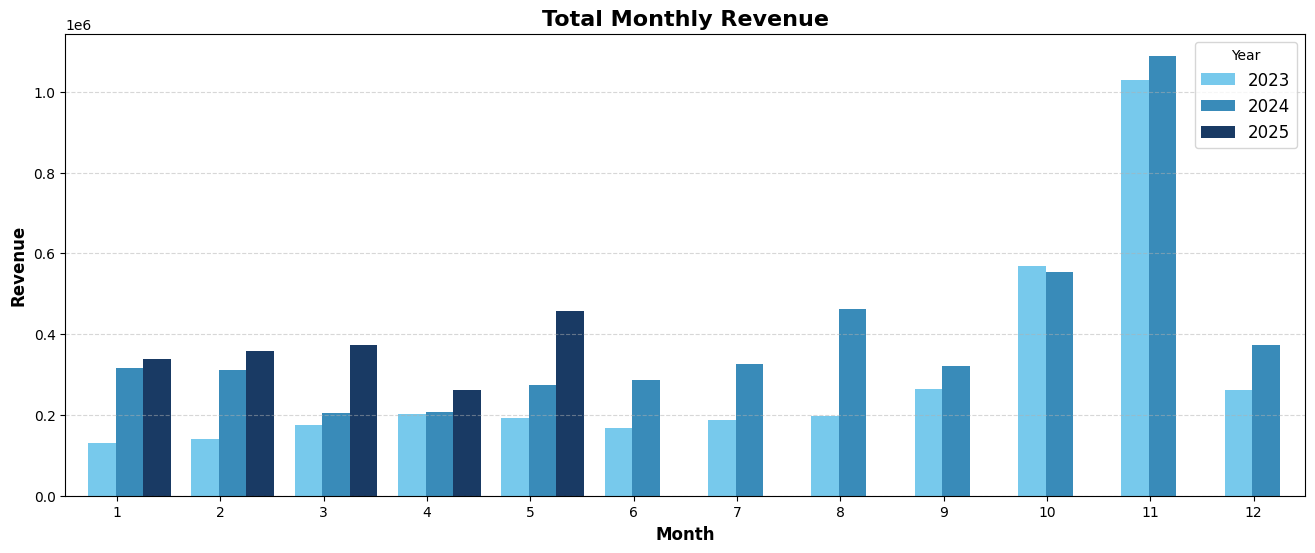

In [29]:
plt.figure(figsize=(16, 6))

color_month   = ["#64d1ff", "#2491ce", "#0d3870"] # Define a color map for the bars

color_annual  = ['#FF6347', '#FF4500', '#DC143C']

# color_map = ["#64d1ff", "#2491ce", "#1b5e7a", "#0d2f3c"]
ax_monthly   = sns.barplot(data=monthly_revenue, x='MONTH', y='SALES', hue='YEAR', palette=color_month)

for container in ax_monthly.containers:    
    for bar in container:
        # Change the width of the bar
        # bar.get_width() returns the original width of the bar, you can adjust it as needed
        original_width = bar.get_width()
        new_width = original_width * 0.1 # adjust the width as needed
        bar.set_x(bar.get_x() + (original_width - new_width) / 2) # Align the bar to the center of the month position
        

plt.title('Total Monthly Revenue',fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12, fontweight ='bold')
plt.ylabel('Revenue', fontsize=12, fontweight = 'bold')
plt.legend(title='Year', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

- The chart indicates that 2024 recorded a substantial revenue growth compared to 2003. 
-  Over the years, sales have remained stable throughout the first nine months before surging from October onwards. Therefore, I recommend increasing stock levels starting in October to ensure adequate inventory is available."
- Specially, November emerged as the top-performing month, so we should run advertisement and offer multiple promotions for demand stimulation.

#### Quarter Chart

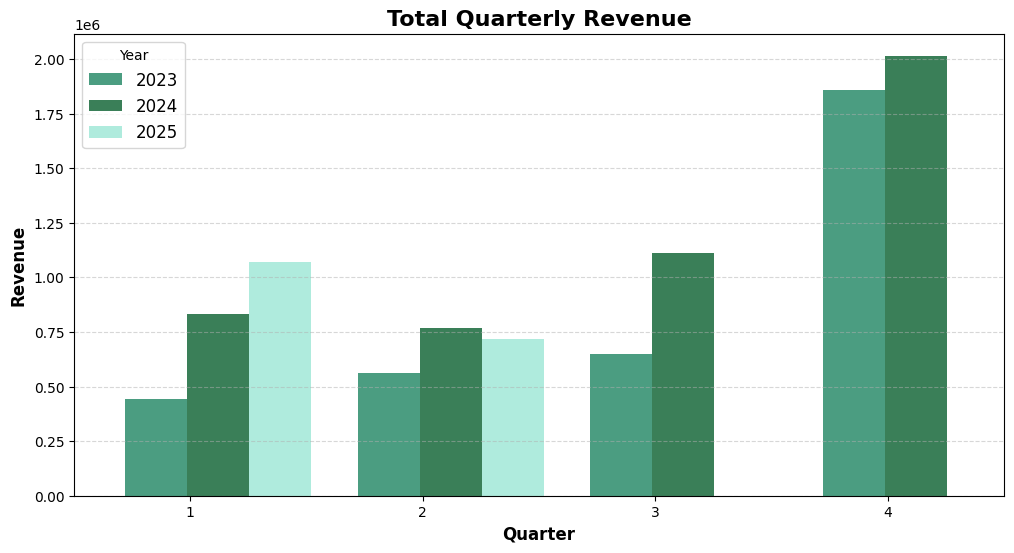

In [30]:
plt.figure(figsize=(12, 6))
color_quarter = ['#3DAB85', '#2E8B57', "#A5F5E2"]
ax_quarterly = sns.barplot(data=quarterly_revenue, x='QUARTER', y='SALES', hue='YEAR', palette=color_quarter)

for container in ax_quarterly.containers:    
    for bar in container:
        # Change the width of the bar
        # bar.get_width() returns the original width of the bar, you can adjust it as needed
        original_width = bar.get_width()
        new_width = original_width * 0.1 # adjust the width as needed
        bar.set_x(bar.get_x() + (original_width - new_width) / 2) # Align the bar to the center of the month position
        

plt.title('Total Quarterly Revenue',fontsize=16, fontweight='bold')
plt.xlabel('Quarter', fontsize=12, fontweight = 'bold')
plt.ylabel('Revenue', fontsize=12, fontweight = 'bold')
plt.legend(title='Year', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

- A comparison between 2023 and 2024 indicates that Q4 recorded the highest profit, approximately 1.5 times that of Q1.
- Regarding the 2025 outlook, there is a slight downward trend in revenue from Q4 2024 through Q2 2025. This likely represents a post-holiday cooling-off period following the year-end shopping peak

- Suggestion for Q3: We should focus on inventory clearance through price markdowns or 'gift-with-purchase' incentives for new product launches. This period is critical for offloading aged stock and initiating marketing campaigns to ensure we are fully prepared for the Q4 2025 surge.

#### Annual Chart

/var/folders/zn/76sp__ln5qg9wnm0lqlyfl800000gn/T/ipykernel_741/1604993447.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Year', fontsize=12)


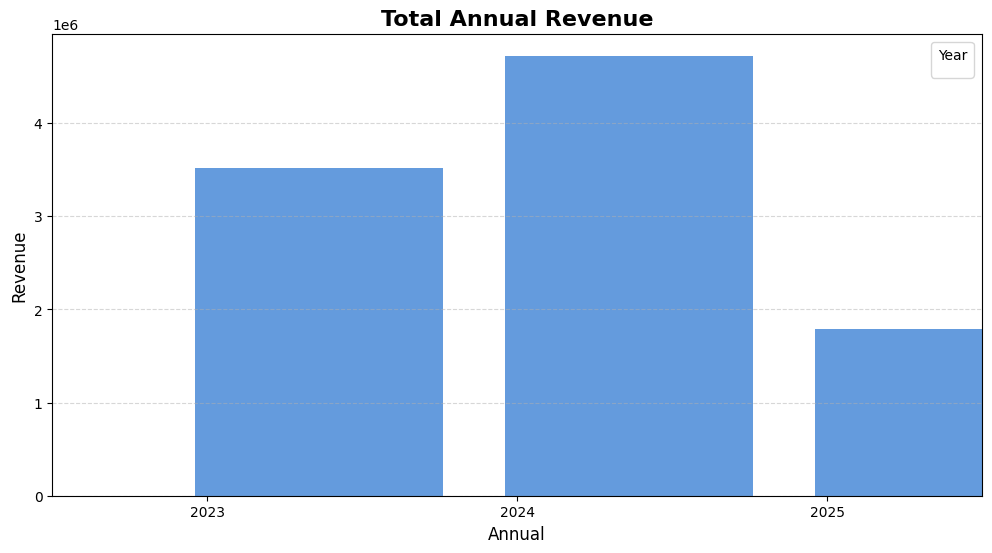

In [31]:
plt.figure(figsize=(12, 6))

ax_annual = sns.barplot(data=annual_revenue, x='YEAR', y='SALES', color="#5099F1")

for container in ax_annual.containers:    
    for bar in container:
        # Change the width of the bar
        # bar.get_width() returns the original width of the bar, you can adjust it as needed
        original_width = bar.get_width()
        new_width = original_width * 0.1 # adjust the width as needed
        bar.set_x(bar.get_x() + (original_width - new_width) / 2) # Align the bar to the center of the month position
        

plt.title('Total Annual Revenue',fontsize=16, fontweight='bold')
plt.xlabel('Annual', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.legend(title='Year', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### Predict future sales

In [94]:
# Add a continuous time index
monthly_revenue['TIME'] = monthly_revenue['YEAR'] + (monthly_revenue['MONTH'] - 1) / 12.0

# Fit a linear regression model to the data
X = sm.add_constant(monthly_revenue['TIME'])
model = sm.OLS(monthly_revenue['SALES'], X).fit()
monthly_revenue['TREND'] = model.predict(X)

monthly_revenue.head(24)





,YEAR,MONTH,SALES,TIME,TREND
0,2003,1,129753.60,2003.000000,206851.974069
1,2003,2,140836.19,2003.083333,216787.741562
2,2003,3,174504.90,2003.166667,226723.509054
3,2003,4,201609.55,2003.250000,236659.276547
4,2003,5,192673.11,2003.333333,246595.044040
5,2003,6,168082.56,2003.416667,256530.811532
6,2003,7,187731.88,2003.500000,266466.579025
7,2003,8,197809.30,2003.583333,276402.346517
8,2003,9,263973.36,2003.666667,286338.114010
9,2003,10,568290.97,2003.750000,296273.881503


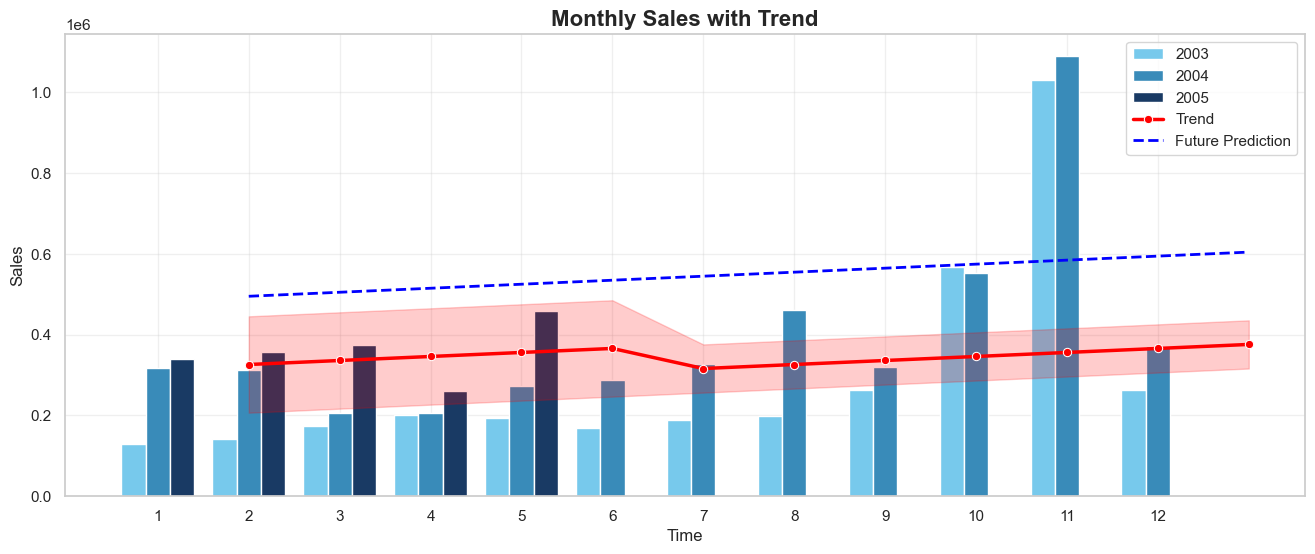

In [ ]:
# Create future time index for the next 12 months
last_time = monthly_revenue['TIME'].max()
future_time = np.arange(last_time + 1/12, last_time + 13/12, 1/12)
future_X = sm.add_constant(future_time)

# Predict future sales
future_sales = model.predict(future_X)


plt.figure(figsize=(16, 6))
sns.barplot(data=monthly_revenue, 
             x     = 'MONTH', 
             y     = 'SALES', 
             hue   =  "YEAR",
             palette = color_month, 
             dodge =True)

# Line plot Trend (seaborn)
sns.lineplot(
    data=monthly_revenue,
    x='MONTH',
    y='TREND',
    color='red',
    linewidth=2.5,
    marker='o',
    label='Trend'
            )

plt.title('Monthly Sales with Trend', fontsize=16, fontweight='bold')
plt.plot(range(1, 13), future_sales, color='blue', linestyle='dashed', linewidth=2, label='Future Prediction')
plt.xlabel('Time', fontsize=12, fontweight = 'bold')
plt.ylabel('Sales', fontsize=12, fontweight = 'bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The red line shows that the average monthly sales are gradually increasing in a steady manner.

### 3.2. Analyze sales of each product line

In [96]:
df.head(5)



,ORDERNUMBER,ORDERDATE,STATUS,SALES,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALESPERSON,PRODUCTCODE,INVENTORY,PRODUCTLINE,MSRP,MONTH,QUARTER,YEAR
0,10107,2003-02-24,Shipped,2871.00,30,95.70,2,Timothy Ortiz,S10_1678,10,Motorcycles,95,2,1,2003
1,10121,2003-05-07,Shipped,2765.90,34,81.35,5,Steven Elliott,S10_1678,13,Motorcycles,95,5,2,2003
2,10134,2003-07-01,Shipped,3884.34,41,94.74,2,Amy Thomas,S10_1678,13,Motorcycles,95,7,3,2003
3,10145,2003-08-25,Shipped,3746.70,45,83.26,6,Cheryl Wilson,S10_1678,49,Motorcycles,95,8,3,2003
4,10159,2003-10-10,Shipped,5205.27,49,100.00,14,Kenneth Waters,S10_1678,19,Motorcycles,95,10,4,2003


In [111]:
# Calculate the annual sales by each product line with pivot table
df_annual_productline = pd.pivot_table(df, 
                                       values='SALES', 
                                       index='PRODUCTLINE', 
                                       columns='YEAR', 
                                       aggfunc='sum', 
                                       margins=True, 
                                       margins_name='Grand Total')

df_annual_productline = df_annual_productline.drop('Grand Total').drop(columns='Grand Total')
df_annual_productline



YEAR,2003,2004,2005
PRODUCTLINE,,,
Classic Cars,2306780.10,3008621.91,1109656.61
Motorcycles,434719.46,814553.91,225619.21
Planes,121541.97,316549.08,193873.73
Ships,11496.55,16221.13,15139.12
Trains,1711.26,20146.32,NaN
Trucks and Buses,196432.67,144092.97,93537.48
Vintage Cars,444297.53,403977.28,153660.56


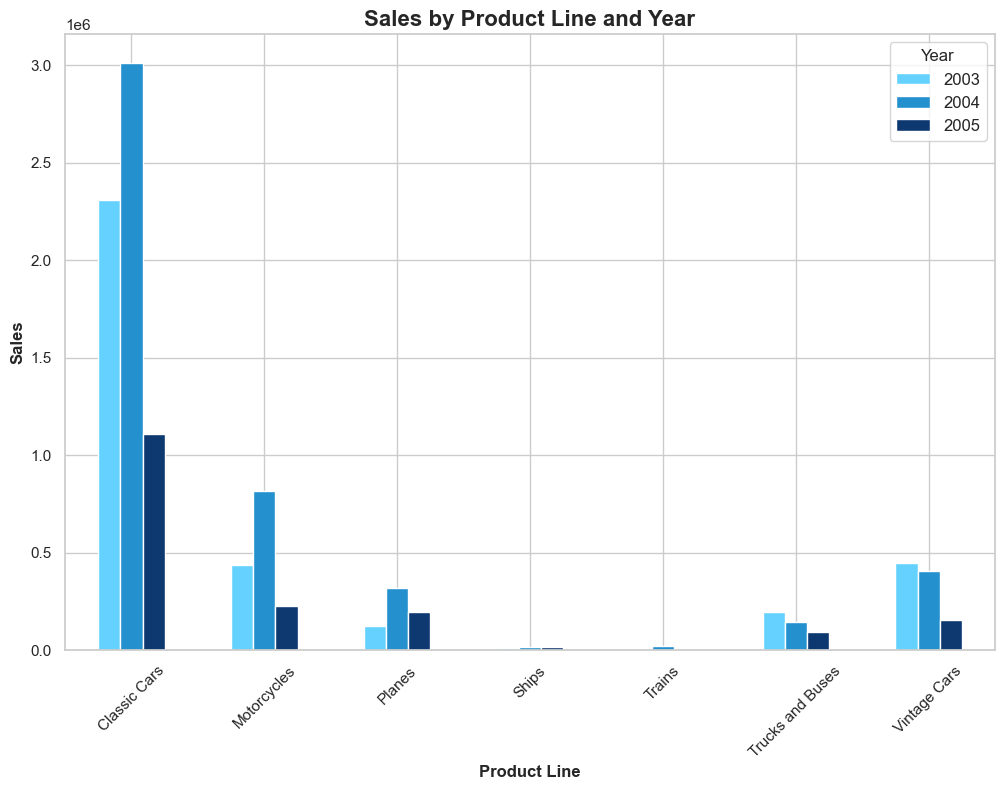

In [132]:
# Plot the pivot table data (excluding the Grand Total row and column)
df_annual_productline.plot(kind='bar', figsize=(12, 8), color =color_month)
plt.title('Sales by Product Line and Year', fontsize = 16, fontweight='bold')
plt.xlabel('Product Line', fontsize=12, fontweight = 'bold')
plt.ylabel('Sales', fontsize=12, fontweight='bold')
plt.legend(title='Year', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### 3.3. Analyze warehouse status by product

In [133]:
# Filter the data to include only rows with STATUS = 'In Process'
filtered_df = df[df['STATUS'] == 'In Process']
filtered_df.head()

,ORDERNUMBER,ORDERDATE,STATUS,SALES,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALESPERSON,PRODUCTCODE,INVENTORY,PRODUCTLINE,MSRP,MONTH,QUARTER,YEAR
53,10424,2005-05-31,In Process,12001.00,50,100.0,6,Amy Sharp,S10_1949,50,Classic Cars,214,5,2,2005
160,10425,2005-05-31,In Process,5894.94,38,100.0,12,Leslie Turner,S10_4962,19,Classic Cars,147,5,2,2005
239,10424,2005-05-31,In Process,7969.36,49,100.0,3,Kayla Johnson,S10_1949,50,Classic Cars,214,5,2,2005
393,10425,2005-05-31,In Process,4692.60,33,100.0,4,Kimberly Walsh,S10_4962,19,Classic Cars,147,5,2,2005
447,10424,2005-05-31,In Process,7182.00,54,100.0,5,Ruben Torres,S10_1949,50,Classic Cars,214,5,2,2005


In [134]:
quantity_ordered_sum = filtered_df.groupby("PRODUCTCODE")["QUANTITYORDERED"].sum()
quantity_ordered_sum

PRODUCTCODE
S10_1949    269
S10_4962    427
S18_1342     76
S18_1749    532
S18_2795     75
S18_2949    111
Name: QUANTITYORDERED, dtype: int64

In [135]:
df_warehouse.head()

,ORDERNUMBER,PRODUCTCODE,INVENTORY
0,10107,S10_1678,10
1,10121,S10_1678,13
2,10134,S10_1678,13
3,10145,S10_1678,49
4,10159,S10_1678,19


In [137]:
# Filter df_warehouse to only include rows with PRODUCTCODEs that are in quantity_ordered_sum
filtered_inventory = df_warehouse[df_warehouse['PRODUCTCODE'].isin(quantity_ordered_sum.index)]

filtered_inventory

,ORDERNUMBER,PRODUCTCODE,INVENTORY
26,10103,S10_1949,15
27,10112,S10_1949,25
28,10126,S10_1949,10
29,10140,S10_1949,28
30,10150,S10_1949,45
...,...,...,...
242,10420,S18_1749,35
254,10255,S18_2795,15
255,10421,S18_2795,47
256,10257,S18_2949,22


In [138]:
inventory_sum = filtered_inventory.groupby("PRODUCTCODE")["INVENTORY"].sum()
inventory_sum

PRODUCTCODE
S10_1949    862
S10_4962    414
S18_1342    597
S18_1749    251
S18_2795     62
S18_2949     34
Name: INVENTORY, dtype: int64

In [140]:
# Convert the Series to DataFrames
quantity_ordered_df = quantity_ordered_sum.reset_index()
inventory_df = inventory_sum.reset_index()

# Merge the DataFrames on PRODUCTCODE
merged_df = pd.merge(inventory_df, quantity_ordered_df, on="PRODUCTCODE", how="inner")

# Rename columns for clarity
merged_df.åcolumns = ["PRODUCTCODE", "INVENTORY", "QUANTITYORDERED"]

# Add the difference column
merged_df["DIF"] = merged_df["INVENTORY"] - merged_df["QUANTITYORDERED"]

merged_df.head()

/var/folders/zn/76sp__ln5qg9wnm0lqlyfl800000gn/T/ipykernel_1828/166682470.py:9: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  merged_df.åcolumns = ["PRODUCTCODE", "INVENTORY", "QUANTITYORDERED"]


,PRODUCTCODE,INVENTORY,QUANTITYORDERED,DIF
0,S10_1949,862,269,593
1,S10_4962,414,427,-13
2,S18_1342,597,76,521
3,S18_1749,251,532,-281
4,S18_2795,62,75,-13


In [144]:
# Filter rows where DIF is negative
negative_dif_df = merged_df[merged_df["DIF"] < 0]

print("List of products with negative DIF (INVENTORY < QUANTITYORDERED):")
print(negative_dif_df[["PRODUCTCODE", "INVENTORY", "QUANTITYORDERED", "DIF"]])

List of products with negative DIF (INVENTORY < QUANTITYORDERED):
  PRODUCTCODE  INVENTORY  QUANTITYORDERED  DIF
1    S10_4962        414              427  -13
3    S18_1749        251              532 -281
4    S18_2795         62               75  -13
5    S18_2949         34              111  -77


### 3.4. Analyze TOP best sales staff

In [145]:
# Create the pivot table
pivot_table_TOP_staff = pd.pivot_table(
    df,
    values='SALES',
    index=['SALESPERSON'],
    columns=['YEAR', 'QUARTER'],
    aggfunc='sum',
    # margins=True, # To include totals if desired
    fill_value=0
)

# Calculate the total sales for each salesperson
pivot_table_TOP_staff['Total'] = pivot_table_TOP_staff.sum(axis=1)

# Sort by total sales in descending order and select the top 4
top_4_salespersons = pivot_table_TOP_staff.sort_values(by='Total', ascending=False).head(4)

top_4_salespersons

YEAR                    2003                                     2004  \
QUARTER                    1         2         3          4         1   
SALESPERSON                                                             
Kenneth Waters      45301.08  20970.03  12751.03   99134.83  51331.24   
Ruben Torres        20110.08  41057.68  27824.83  119279.25  57685.45   
Barbara Roberts     16200.32   6575.27  52027.40   88644.51  67372.26   
Jessica Hutchinson  22152.70  45981.54  46115.13  102375.89  35758.02   

YEAR                                                   2005            \
QUARTER                    2         3          4         1         2   
SALESPERSON                                                             
Kenneth Waters      51161.62  73263.40  130133.69  44192.83  36674.62   
Ruben Torres        59257.53  46851.62   82049.40  58971.67  40367.50   
Barbara Roberts     26020.44  88265.55  107675.77  65732.33  32604.18   
Jessica Hutchinson  38783.72  46179.58  116226.68  45909.58  45220.33   

YEAR                    Total  
QUARTER                        
SALESPERSON                    
Kenneth Waters      564914.37  
Ruben Torres        553455.01  
Barbara Roberts     551118.03  
Jessica Hutchinson  544703.17

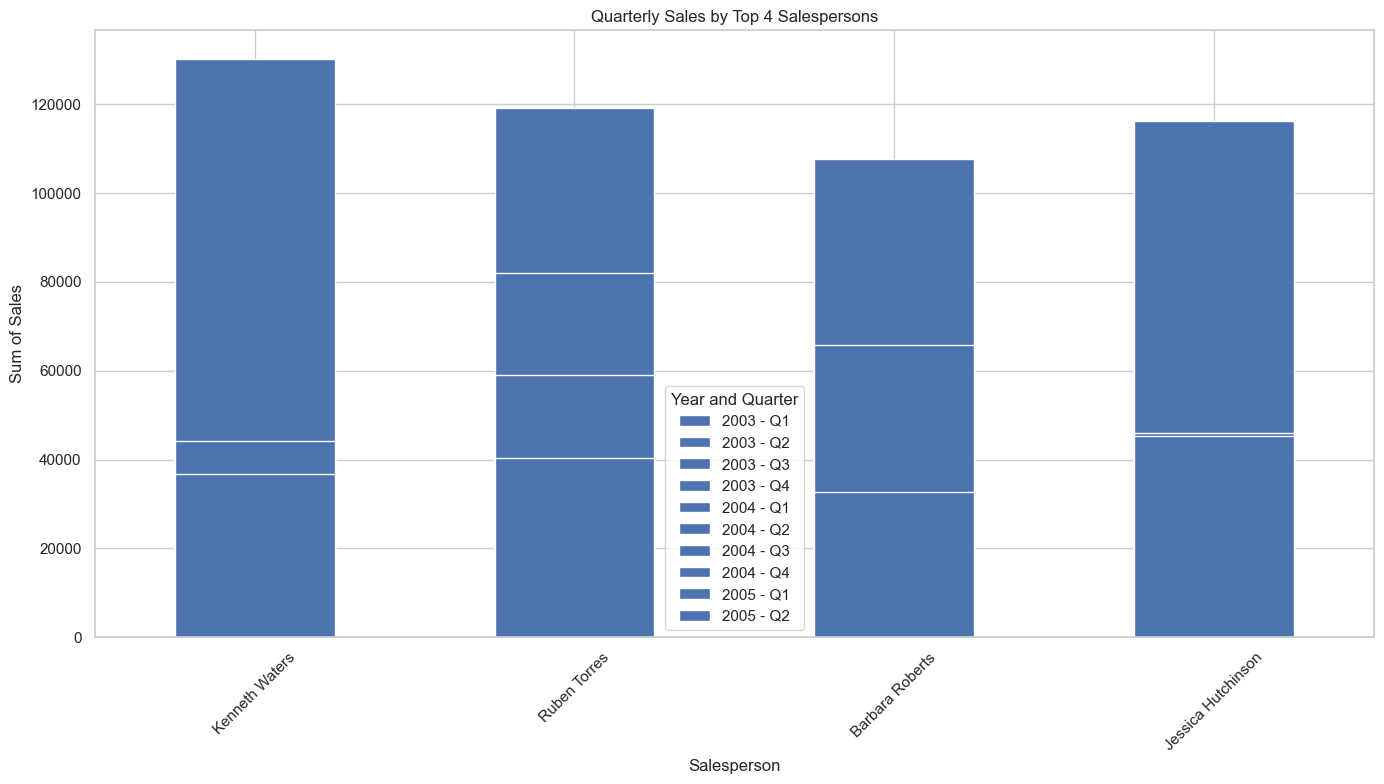

In [146]:
# Drop the 'Total' column as we don't need it for plotting
plot_data = top_4_salespersons.drop(columns='Total')

# Unstack the DataFrame for easier plotting
unstacked_data = plot_data.unstack().reset_index()
unstacked_data.columns = ['Year', 'Quarter', 'Salesperson', 'Sales']

# Plotting
fig, ax = plt.subplots(figsize=(14, 8))

# Create a bar plot
for key, grp in unstacked_data.groupby(['Year', 'Quarter']):
    ax = grp.plot(ax=ax, kind='bar', x='Salesperson', y='Sales', label=f'{key[0]} - Q{key[1]}')

# Customize the plot
ax.set_title('Quarterly Sales by Top 4 Salespersons')
ax.set_xlabel('Salesperson')
ax.set_ylabel('Sum of Sales')
ax.legend(title='Year and Quarter')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()